In [176]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import CSV Files and Investigate

In [177]:
df1 = pd.read_csv("data/robot_standby.csv")
df1

,Unnamed: 0,time,robots_ids
0,0,2025-08-01 12:50:00,"18e6e78885673afa616606982f881ffb9e6dccb2,20c8e..."
1,1,2025-08-01 12:50:00,"223d6cfdd815c1e3738f3e4ffe31139e3906d871,1cdd4..."
2,2,2025-08-01 12:50:00,"3bb178e9c9f5bcc592e4fc178790f0bab83c24c1,f8c69..."
3,3,2025-08-01 12:50:00,"6cb38ae52c5ccec7ab0f5b89b4b4bbf045225905,65be2..."
4,4,2025-08-01 12:50:00,"61473f82bbe411e577a2c4fbc603f069ab4afec3,ba442..."
...,...,...,...
8081,8081,2025-08-02 03:45:00,"61237f58b52ac620797a4393ca3d347903c2fc5b,92e6e..."
8082,8082,2025-08-02 03:45:00,"68fcd0768f292ffb58c077582adca95754cf6119,cf83a..."
8083,8083,2025-08-02 03:45:00,"b4e07cbd9aff63093d5c1641eff8f2edcf56e965,e62ce..."
8084,8084,2025-08-02 03:50:00,"99e3839c1c4681c705c0b309a3b763bb34a13b2b,61877..."


In [178]:
df2 = pd.read_csv("data/robot_name_info.tsv", sep="\t").drop("Unnamed: 0", axis=1)
df2

,robot_id,robot_name
0,a0e7bad2868ac7777a6c584fb464133bc9b58967,runner.RobotOptimus
1,2d97f27974e05239af43e77b9589aaef317203fe,runner.RobotOptimus
2,df6cff510c5476e6045cf6a53dc14ea77b7addc7,runner.RobotOptimus
3,02cfcc997c7f08ea24df9f98acebebf684a848f7,runner.RobotOptimus
4,b33a78d87d9cee0cd44d18ed0460420461812b38,runner.RobotOptimus
...,...,...
1146,f79e99f40781bb7b304b845796b61213977d28fd,runner.PMUTBot
1147,62faccd3f03b892af47d09ce7225a36e532a4654,runner.PMUTBot
1148,c681177b342be4ae2ab289a5cf3d50f174f6b8f0,runner.PMUTBot
1149,5101369fde4c0c62e8241af61b82911454859cf7,runner.JasmineBot


In [179]:
df3 = pd.read_csv("data/robot_queued.csv").drop("Unnamed: 0", axis=1)
df3

,time,id
0,2025-08-01 12:50:41.613,443f9025aa100b1769c72b53f6295b149041edd7
1,2025-08-01 12:50:41.718,620c3221de29d098d04b6264ebc54333ba4daacf
2,2025-08-01 12:50:41.720,b4e7626e7122dae33d5d09f4dd6765592209d5ea
3,2025-08-01 12:50:41.948,9b3e7ffa7b67560416e27b69fdc2a5e3f451e608
4,2025-08-01 12:50:41.991,5b4cc19be8fd7152b968962b6310ae9443bd6c96
...,...,...
474662,2025-08-02 03:50:16.946,f52b1b3248539aa34baa810d7e9e19f66a218d49
474663,2025-08-02 03:50:16.961,52e3235d5641bde5933542960643568d79e2e9dd
474664,2025-08-02 03:50:17.059,c217b94db23391bd1f1b176a74f10632b32c9f0b
474665,2025-08-02 03:50:17.589,7b3c4017ce2dee9941072191ea9c897e59af3c7a


# Preprocess Standby Data

In [180]:
df1 = df1.iloc[:, -2:]
df1["time"] = pd.to_datetime(df1["time"])
df1

,time,robots_ids
0,2025-08-01 12:50:00,"18e6e78885673afa616606982f881ffb9e6dccb2,20c8e..."
1,2025-08-01 12:50:00,"223d6cfdd815c1e3738f3e4ffe31139e3906d871,1cdd4..."
2,2025-08-01 12:50:00,"3bb178e9c9f5bcc592e4fc178790f0bab83c24c1,f8c69..."
3,2025-08-01 12:50:00,"6cb38ae52c5ccec7ab0f5b89b4b4bbf045225905,65be2..."
4,2025-08-01 12:50:00,"61473f82bbe411e577a2c4fbc603f069ab4afec3,ba442..."
...,...,...
8081,2025-08-02 03:45:00,"61237f58b52ac620797a4393ca3d347903c2fc5b,92e6e..."
8082,2025-08-02 03:45:00,"68fcd0768f292ffb58c077582adca95754cf6119,cf83a..."
8083,2025-08-02 03:45:00,"b4e07cbd9aff63093d5c1641eff8f2edcf56e965,e62ce..."
8084,2025-08-02 03:50:00,"99e3839c1c4681c705c0b309a3b763bb34a13b2b,61877..."


In [181]:
df1 = df1.assign(id = df1["robots_ids"].str.split(","))
df1

,time,robots_ids,id
0,2025-08-01 12:50:00,"18e6e78885673afa616606982f881ffb9e6dccb2,20c8e...","[18e6e78885673afa616606982f881ffb9e6dccb2, 20c..."
1,2025-08-01 12:50:00,"223d6cfdd815c1e3738f3e4ffe31139e3906d871,1cdd4...","[223d6cfdd815c1e3738f3e4ffe31139e3906d871, 1cd..."
2,2025-08-01 12:50:00,"3bb178e9c9f5bcc592e4fc178790f0bab83c24c1,f8c69...","[3bb178e9c9f5bcc592e4fc178790f0bab83c24c1, f8c..."
3,2025-08-01 12:50:00,"6cb38ae52c5ccec7ab0f5b89b4b4bbf045225905,65be2...","[6cb38ae52c5ccec7ab0f5b89b4b4bbf045225905, 65b..."
4,2025-08-01 12:50:00,"61473f82bbe411e577a2c4fbc603f069ab4afec3,ba442...","[61473f82bbe411e577a2c4fbc603f069ab4afec3, ba4..."
...,...,...,...
8081,2025-08-02 03:45:00,"61237f58b52ac620797a4393ca3d347903c2fc5b,92e6e...","[61237f58b52ac620797a4393ca3d347903c2fc5b, 92e..."
8082,2025-08-02 03:45:00,"68fcd0768f292ffb58c077582adca95754cf6119,cf83a...","[68fcd0768f292ffb58c077582adca95754cf6119, cf8..."
8083,2025-08-02 03:45:00,"b4e07cbd9aff63093d5c1641eff8f2edcf56e965,e62ce...","[b4e07cbd9aff63093d5c1641eff8f2edcf56e965, e62..."
8084,2025-08-02 03:50:00,"99e3839c1c4681c705c0b309a3b763bb34a13b2b,61877...","[99e3839c1c4681c705c0b309a3b763bb34a13b2b, 618..."


In [182]:
df1 = df1.explode("id")
df1

,time,robots_ids,id
0,2025-08-01 12:50:00,"18e6e78885673afa616606982f881ffb9e6dccb2,20c8e...",18e6e78885673afa616606982f881ffb9e6dccb2
0,2025-08-01 12:50:00,"18e6e78885673afa616606982f881ffb9e6dccb2,20c8e...",20c8e87450c0fc83229988bf2f0437ed97745404
0,2025-08-01 12:50:00,"18e6e78885673afa616606982f881ffb9e6dccb2,20c8e...",9a1f9a0af86e1a620442b0d6ac8136ee53740f36
0,2025-08-01 12:50:00,"18e6e78885673afa616606982f881ffb9e6dccb2,20c8e...",c3f3d354400f402cf350c69fa6117857f57a76b4
0,2025-08-01 12:50:00,"18e6e78885673afa616606982f881ffb9e6dccb2,20c8e...",954bafad38ac945817d312baa2678102942ce6de
...,...,...,...
8085,2025-08-02 03:50:00,"3ff1df655006a77911d9b9ff0d2437aa490a04ec,d74dd...",7fe489130e8d445667960b921f990f3968a92813
8085,2025-08-02 03:50:00,"3ff1df655006a77911d9b9ff0d2437aa490a04ec,d74dd...",ec9b6d63f014e3ad2f874fb96c85567cb823e8ed
8085,2025-08-02 03:50:00,"3ff1df655006a77911d9b9ff0d2437aa490a04ec,d74dd...",80cb9107145af39c94de14272480f41775c71e4d
8085,2025-08-02 03:50:00,"3ff1df655006a77911d9b9ff0d2437aa490a04ec,d74dd...",f52b1b3248539aa34baa810d7e9e19f66a218d49


In [183]:
df1 = df1.drop("robot_ids", axis=1, errors="ignore")
df1

,time,robots_ids,id
0,2025-08-01 12:50:00,"18e6e78885673afa616606982f881ffb9e6dccb2,20c8e...",18e6e78885673afa616606982f881ffb9e6dccb2
0,2025-08-01 12:50:00,"18e6e78885673afa616606982f881ffb9e6dccb2,20c8e...",20c8e87450c0fc83229988bf2f0437ed97745404
0,2025-08-01 12:50:00,"18e6e78885673afa616606982f881ffb9e6dccb2,20c8e...",9a1f9a0af86e1a620442b0d6ac8136ee53740f36
0,2025-08-01 12:50:00,"18e6e78885673afa616606982f881ffb9e6dccb2,20c8e...",c3f3d354400f402cf350c69fa6117857f57a76b4
0,2025-08-01 12:50:00,"18e6e78885673afa616606982f881ffb9e6dccb2,20c8e...",954bafad38ac945817d312baa2678102942ce6de
...,...,...,...
8085,2025-08-02 03:50:00,"3ff1df655006a77911d9b9ff0d2437aa490a04ec,d74dd...",7fe489130e8d445667960b921f990f3968a92813
8085,2025-08-02 03:50:00,"3ff1df655006a77911d9b9ff0d2437aa490a04ec,d74dd...",ec9b6d63f014e3ad2f874fb96c85567cb823e8ed
8085,2025-08-02 03:50:00,"3ff1df655006a77911d9b9ff0d2437aa490a04ec,d74dd...",80cb9107145af39c94de14272480f41775c71e4d
8085,2025-08-02 03:50:00,"3ff1df655006a77911d9b9ff0d2437aa490a04ec,d74dd...",f52b1b3248539aa34baa810d7e9e19f66a218d49


In [184]:
df1 = df1.drop_duplicates(subset=["id"])
df1

,time,robots_ids,id
0,2025-08-01 12:50:00,"18e6e78885673afa616606982f881ffb9e6dccb2,20c8e...",18e6e78885673afa616606982f881ffb9e6dccb2
0,2025-08-01 12:50:00,"18e6e78885673afa616606982f881ffb9e6dccb2,20c8e...",20c8e87450c0fc83229988bf2f0437ed97745404
0,2025-08-01 12:50:00,"18e6e78885673afa616606982f881ffb9e6dccb2,20c8e...",9a1f9a0af86e1a620442b0d6ac8136ee53740f36
0,2025-08-01 12:50:00,"18e6e78885673afa616606982f881ffb9e6dccb2,20c8e...",c3f3d354400f402cf350c69fa6117857f57a76b4
0,2025-08-01 12:50:00,"18e6e78885673afa616606982f881ffb9e6dccb2,20c8e...",954bafad38ac945817d312baa2678102942ce6de
...,...,...,...
8085,2025-08-02 03:50:00,"3ff1df655006a77911d9b9ff0d2437aa490a04ec,d74dd...",8c4e5850e87e0643fcf45e331782215d19f4e2ff
8085,2025-08-02 03:50:00,"3ff1df655006a77911d9b9ff0d2437aa490a04ec,d74dd...",7fe489130e8d445667960b921f990f3968a92813
8085,2025-08-02 03:50:00,"3ff1df655006a77911d9b9ff0d2437aa490a04ec,d74dd...",ec9b6d63f014e3ad2f874fb96c85567cb823e8ed
8085,2025-08-02 03:50:00,"3ff1df655006a77911d9b9ff0d2437aa490a04ec,d74dd...",80cb9107145af39c94de14272480f41775c71e4d


# Preprocess Queued Data

In [185]:
df3

,time,id
0,2025-08-01 12:50:41.613,443f9025aa100b1769c72b53f6295b149041edd7
1,2025-08-01 12:50:41.718,620c3221de29d098d04b6264ebc54333ba4daacf
2,2025-08-01 12:50:41.720,b4e7626e7122dae33d5d09f4dd6765592209d5ea
3,2025-08-01 12:50:41.948,9b3e7ffa7b67560416e27b69fdc2a5e3f451e608
4,2025-08-01 12:50:41.991,5b4cc19be8fd7152b968962b6310ae9443bd6c96
...,...,...
474662,2025-08-02 03:50:16.946,f52b1b3248539aa34baa810d7e9e19f66a218d49
474663,2025-08-02 03:50:16.961,52e3235d5641bde5933542960643568d79e2e9dd
474664,2025-08-02 03:50:17.059,c217b94db23391bd1f1b176a74f10632b32c9f0b
474665,2025-08-02 03:50:17.589,7b3c4017ce2dee9941072191ea9c897e59af3c7a


In [186]:
df3["time"] = pd.to_datetime(df3["time"])
df3 = df3.drop_duplicates(subset=["id"])
df3

,time,id
0,2025-08-01 12:50:41.613,443f9025aa100b1769c72b53f6295b149041edd7
1,2025-08-01 12:50:41.718,620c3221de29d098d04b6264ebc54333ba4daacf
2,2025-08-01 12:50:41.720,b4e7626e7122dae33d5d09f4dd6765592209d5ea
3,2025-08-01 12:50:41.948,9b3e7ffa7b67560416e27b69fdc2a5e3f451e608
4,2025-08-01 12:50:41.991,5b4cc19be8fd7152b968962b6310ae9443bd6c96
...,...,...
474662,2025-08-02 03:50:16.946,f52b1b3248539aa34baa810d7e9e19f66a218d49
474663,2025-08-02 03:50:16.961,52e3235d5641bde5933542960643568d79e2e9dd
474664,2025-08-02 03:50:17.059,c217b94db23391bd1f1b176a74f10632b32c9f0b
474665,2025-08-02 03:50:17.589,7b3c4017ce2dee9941072191ea9c897e59af3c7a


In [187]:
merged = pd.merge(df1, df3, on="id", suffixes=("_standby", "_queued"))
merged

,time_standby,robots_ids,id,time_queued
0,2025-08-01 12:50:00,"18e6e78885673afa616606982f881ffb9e6dccb2,20c8e...",18e6e78885673afa616606982f881ffb9e6dccb2,2025-08-01 12:53:34.273
1,2025-08-01 12:50:00,"18e6e78885673afa616606982f881ffb9e6dccb2,20c8e...",20c8e87450c0fc83229988bf2f0437ed97745404,2025-08-01 12:53:34.541
2,2025-08-01 12:50:00,"18e6e78885673afa616606982f881ffb9e6dccb2,20c8e...",9a1f9a0af86e1a620442b0d6ac8136ee53740f36,2025-08-01 12:53:33.888
3,2025-08-01 12:50:00,"18e6e78885673afa616606982f881ffb9e6dccb2,20c8e...",c3f3d354400f402cf350c69fa6117857f57a76b4,2025-08-01 12:53:34.248
4,2025-08-01 12:50:00,"18e6e78885673afa616606982f881ffb9e6dccb2,20c8e...",954bafad38ac945817d312baa2678102942ce6de,2025-08-01 12:53:33.814
...,...,...,...,...
412077,2025-08-02 03:50:00,"3ff1df655006a77911d9b9ff0d2437aa490a04ec,d74dd...",8c4e5850e87e0643fcf45e331782215d19f4e2ff,2025-08-02 03:50:06.275
412078,2025-08-02 03:50:00,"3ff1df655006a77911d9b9ff0d2437aa490a04ec,d74dd...",7fe489130e8d445667960b921f990f3968a92813,2025-08-02 03:50:08.508
412079,2025-08-02 03:50:00,"3ff1df655006a77911d9b9ff0d2437aa490a04ec,d74dd...",ec9b6d63f014e3ad2f874fb96c85567cb823e8ed,2025-08-02 03:50:09.561
412080,2025-08-02 03:50:00,"3ff1df655006a77911d9b9ff0d2437aa490a04ec,d74dd...",80cb9107145af39c94de14272480f41775c71e4d,2025-08-02 03:50:07.041


In [188]:
merged["delayed"] = merged["time_queued"] - merged["time_standby"]
merged = merged[["id", "time_standby", "time_queued", "delayed"]]
merged

,id,time_standby,time_queued,delayed
0,18e6e78885673afa616606982f881ffb9e6dccb2,2025-08-01 12:50:00,2025-08-01 12:53:34.273,0 days 00:03:34.273000
1,20c8e87450c0fc83229988bf2f0437ed97745404,2025-08-01 12:50:00,2025-08-01 12:53:34.541,0 days 00:03:34.541000
2,9a1f9a0af86e1a620442b0d6ac8136ee53740f36,2025-08-01 12:50:00,2025-08-01 12:53:33.888,0 days 00:03:33.888000
3,c3f3d354400f402cf350c69fa6117857f57a76b4,2025-08-01 12:50:00,2025-08-01 12:53:34.248,0 days 00:03:34.248000
4,954bafad38ac945817d312baa2678102942ce6de,2025-08-01 12:50:00,2025-08-01 12:53:33.814,0 days 00:03:33.814000
...,...,...,...,...
412077,8c4e5850e87e0643fcf45e331782215d19f4e2ff,2025-08-02 03:50:00,2025-08-02 03:50:06.275,0 days 00:00:06.275000
412078,7fe489130e8d445667960b921f990f3968a92813,2025-08-02 03:50:00,2025-08-02 03:50:08.508,0 days 00:00:08.508000
412079,ec9b6d63f014e3ad2f874fb96c85567cb823e8ed,2025-08-02 03:50:00,2025-08-02 03:50:09.561,0 days 00:00:09.561000
412080,80cb9107145af39c94de14272480f41775c71e4d,2025-08-02 03:50:00,2025-08-02 03:50:07.041,0 days 00:00:07.041000


In [189]:
delayed = merged[merged["delayed"] > pd.Timedelta(minutes=60)]
delayed = delayed.sort_values("delayed")
delayed = delayed.reset_index().drop("index", axis=1)
delayed

,id,time_standby,time_queued,delayed
0,48f20068d2fc88284aeadb91eb5d213939442c47,2025-08-01 15:50:00,2025-08-01 16:50:03.249,0 days 01:00:03.249000
1,868faa8da17fc68cc2e4a3a0e8ec22d07dd211a9,2025-08-01 23:30:00,2025-08-02 00:30:05.963,0 days 01:00:05.963000
2,19562ee4436c3bcadc4197ef3a179dac92bad782,2025-08-01 16:00:00,2025-08-01 17:00:13.468,0 days 01:00:13.468000
3,e4aa8a290b1c0d3d749f404c1ed37b029bdd8ab1,2025-08-01 15:50:00,2025-08-01 16:50:14.071,0 days 01:00:14.071000
4,3ec8dfc70389568dc0e80ef82d674d2983d167e5,2025-08-01 23:30:00,2025-08-02 00:30:17.415,0 days 01:00:17.415000
...,...,...,...,...
2492,bd7c9b905d761d027906038c3456e0aceecbe7b1,2025-08-01 17:50:00,2025-08-01 22:09:11.122,0 days 04:19:11.122000
2493,0446889432b1c4d21df012b37d83e7549b469f8e,2025-08-01 15:20:00,2025-08-01 20:39:27.400,0 days 05:19:27.400000
2494,9d1911f881c1e96859592f1626324808f4ba8e74,2025-08-01 15:20:00,2025-08-01 20:39:56.612,0 days 05:19:56.612000
2495,1b55d95249391e94e0c372132e771c3ffc5f9805,2025-08-01 15:20:00,2025-08-01 20:40:46.069,0 days 05:20:46.069000


In [190]:
print("dealyed atom count:", delayed.shape[0])

dealyed atom count: 2497


# Preprocess Name Data

In [198]:
df2

,id,robot_name
0,a0e7bad2868ac7777a6c584fb464133bc9b58967,runner.RobotOptimus
1,2d97f27974e05239af43e77b9589aaef317203fe,runner.RobotOptimus
2,df6cff510c5476e6045cf6a53dc14ea77b7addc7,runner.RobotOptimus
3,02cfcc997c7f08ea24df9f98acebebf684a848f7,runner.RobotOptimus
4,b33a78d87d9cee0cd44d18ed0460420461812b38,runner.RobotOptimus
...,...,...
1146,f79e99f40781bb7b304b845796b61213977d28fd,runner.PMUTBot
1147,62faccd3f03b892af47d09ce7225a36e532a4654,runner.PMUTBot
1148,c681177b342be4ae2ab289a5cf3d50f174f6b8f0,runner.PMUTBot
1149,5101369fde4c0c62e8241af61b82911454859cf7,runner.JasmineBot


In [200]:
df2 = df2.rename(columns={"robot_id":"id"})
df2

,id,robot_name
0,a0e7bad2868ac7777a6c584fb464133bc9b58967,runner.RobotOptimus
1,2d97f27974e05239af43e77b9589aaef317203fe,runner.RobotOptimus
2,df6cff510c5476e6045cf6a53dc14ea77b7addc7,runner.RobotOptimus
3,02cfcc997c7f08ea24df9f98acebebf684a848f7,runner.RobotOptimus
4,b33a78d87d9cee0cd44d18ed0460420461812b38,runner.RobotOptimus
...,...,...
1146,f79e99f40781bb7b304b845796b61213977d28fd,runner.PMUTBot
1147,62faccd3f03b892af47d09ce7225a36e532a4654,runner.PMUTBot
1148,c681177b342be4ae2ab289a5cf3d50f174f6b8f0,runner.PMUTBot
1149,5101369fde4c0c62e8241af61b82911454859cf7,runner.JasmineBot


# Final Merge

In [192]:
merged2 = df2.merge(delayed, on="id")
merged2["delayed_by_min"] = (merged2["delayed"].dt.total_seconds() / 60).round(2)
merged2

,id,robot_name,time_standby,time_queued,delayed,delayed_by_min
0,1f3f422be37d93b52dd15600817836fa62090eb1,runner.XMLinator,2025-08-01 15:45:00,2025-08-01 16:47:55.227,0 days 01:02:55.227000,62.92
1,69c1a7b720a8baeda012270a19a5daa20144c841,runner.CopyDroid,2025-08-01 15:50:00,2025-08-01 16:50:56.872,0 days 01:00:56.872000,60.95
2,ee93ac299fa5d4f36375390028a0b00e42f32b45,runner.CopyDroid,2025-08-01 15:50:00,2025-08-01 16:50:58.053,0 days 01:00:58.053000,60.97
3,ec647784242a3e9d3a28a1262dd0fb81690b9172,runner.JoinerBot,2025-08-01 15:45:00,2025-08-01 16:51:18.095,0 days 01:06:18.095000,66.30
4,beca7c5866d018de57dee2107f61b6fca2cb2360,runner.XMLinator,2025-08-01 15:50:00,2025-08-01 16:51:39.224,0 days 01:01:39.224000,61.65
...,...,...,...,...,...,...
1138,f79e99f40781bb7b304b845796b61213977d28fd,runner.PMUTBot,2025-08-01 21:05:00,2025-08-01 22:40:10.810,0 days 01:35:10.810000,95.18
1139,62faccd3f03b892af47d09ce7225a36e532a4654,runner.PMUTBot,2025-08-01 21:05:00,2025-08-01 22:56:20.793,0 days 01:51:20.793000,111.35
1140,c681177b342be4ae2ab289a5cf3d50f174f6b8f0,runner.PMUTBot,2025-08-01 21:05:00,2025-08-01 23:07:52.691,0 days 02:02:52.691000,122.88
1141,5101369fde4c0c62e8241af61b82911454859cf7,runner.JasmineBot,2025-08-01 22:30:00,2025-08-01 23:55:17.164,0 days 01:25:17.164000,85.29


In [193]:
final = merged2.copy()
final.describe().round(0)

,time_standby,time_queued,delayed,delayed_by_min
count,1143,1143,1143,1143.0
mean,2025-08-01 19:40:13.910761216,2025-08-01 21:16:36.173253632,0 days 01:36:22.262492563,96.0
min,2025-08-01 13:25:00,2025-08-01 14:30:46.472000,0 days 01:00:03.249000,60.0
25%,2025-08-01 18:15:00,2025-08-01 19:32:42.864000,0 days 01:13:26.603500,73.0
50%,2025-08-01 21:05:00,2025-08-01 22:35:22.232000,0 days 01:33:48.493000,94.0
75%,2025-08-01 21:05:00,2025-08-01 22:56:04.588000,0 days 01:54:55.222000,115.0
max,2025-08-01 22:55:00,2025-08-02 00:07:23.472000,0 days 05:39:18.085000,339.0
std,NaN,NaN,0 days 00:28:08.958535116,28.0


# Data Visualization

In [194]:
import matplotlib.pyplot as plt

In [195]:
grouped = final.groupby("robot_name")["delayed_by_min"].mean()
grouped.index = grouped.index.str.split(".").str[-1]
grouped = grouped.sort_values(ascending=False)
grouped

robot_name
RobotOptimus      160.879245
PMUTBot           102.308629
JasmineBot         76.947500
RopeWalker         75.752500
BuildoPlane        73.970000
JesterUnit         73.337500
ProfileBot         72.852658
HappyBot           71.975000
UnitJasBot         70.170000
TestRunner3000     69.608462
Artifactor         68.073704
Simulatrix         67.710000
XMLinator          67.449583
CaseGenie          67.075833
RunnerBotX         67.040000
IntegronBot        66.390000
JoinerBot          66.300000
ImporterX          64.550000
TestoTron          61.892308
CopyDroid          61.421429
LogiCopy           60.975000
Name: delayed_by_min, dtype: float64

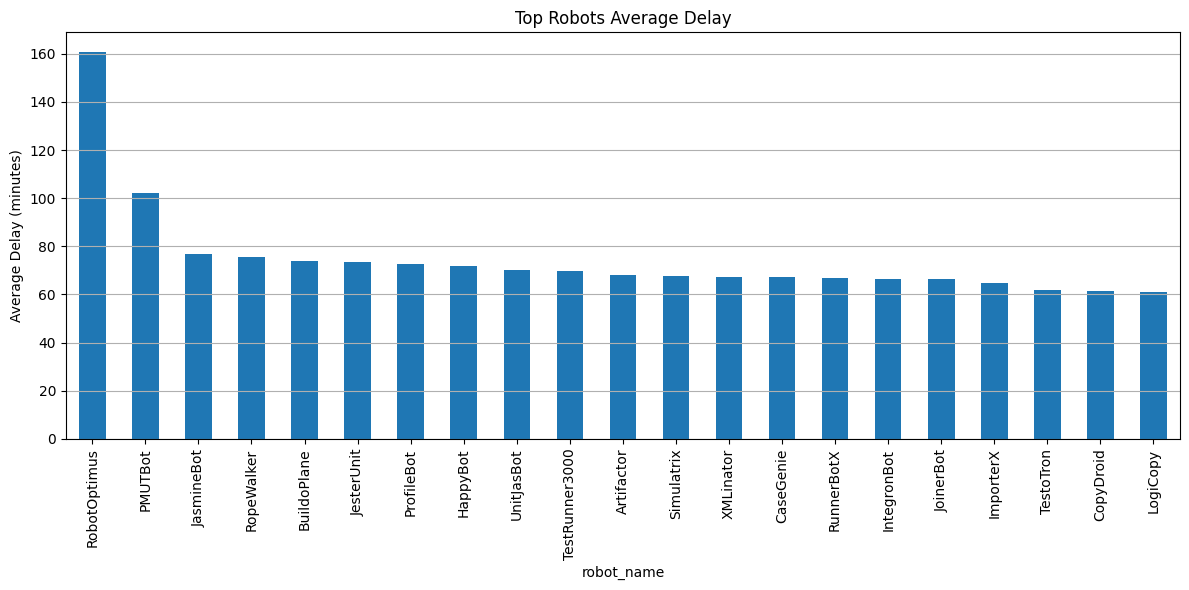

In [196]:
plt.figure(figsize=(12, 6))

grouped.plot(kind="bar")
plt.ylabel("Average Delay (minutes)")
plt.title("Top Robots Average Delay")
plt.tight_layout()
plt.grid(axis="y")
plt.show()

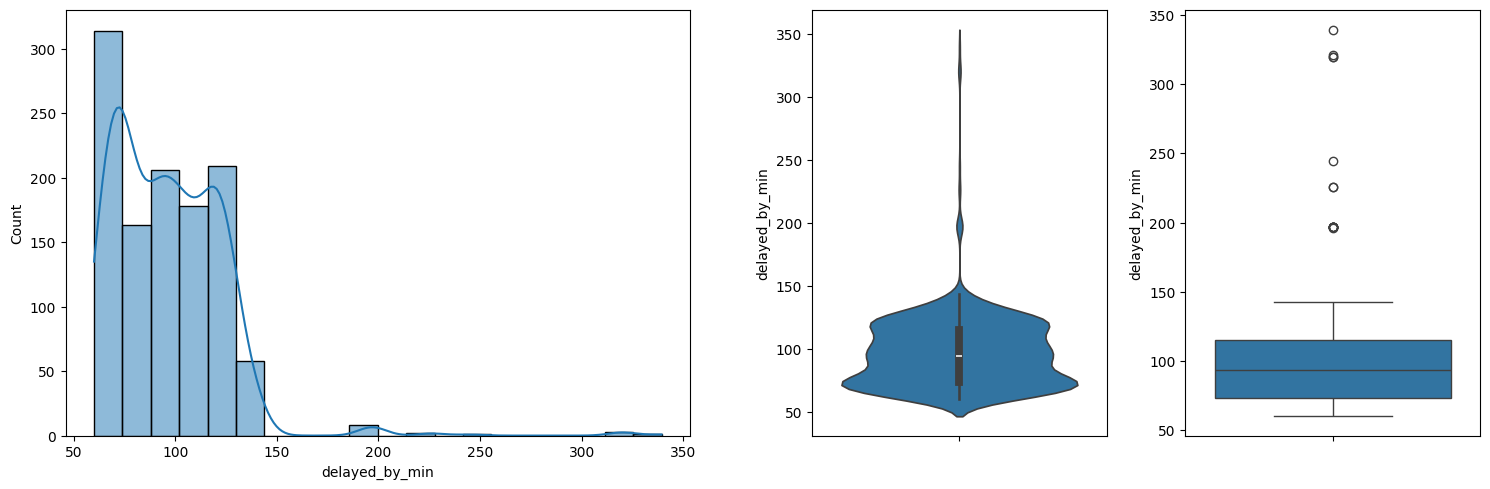

In [197]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.histplot(data=final["delayed_by_min"], bins=20, kde=True)

plt.subplot(1, 4, 3)
sns.violinplot(data=final["delayed_by_min"])

plt.subplot(1,4,4)
sns.boxplot(data=final["delayed_by_min"])

plt.tight_layout()